# B. Kiểm Tra Dữ Liệu Thô

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

it = pd.read_csv("../data/raw/00-itviec_raw.csv")
tc = pd.read_csv("../data/raw/00-topcv_raw.csv")

print(f"ITViec : {it.shape[0]} hàng  ×  {it.shape[1]} cột")
print(f"TopCV  : {tc.shape[0]} hàng  ×  {tc.shape[1]} cột")

ITViec : 751 hàng  ×  15 cột
TopCV  : 4384 hàng  ×  16 cột


## 1. Tổng quan cấu trúc

In [2]:
# Cột của từng nguồn
it_cols = set(it.columns)
tc_cols = set(tc.columns)
only_tc = tc_cols - it_cols
only_it = it_cols - tc_cols
common  = it_cols & tc_cols

print(f"Cột chung ({len(common)})  : {sorted(common)}")
print(f"Chỉ TopCV ({len(only_tc)}) : {sorted(only_tc)}")
print(f"Chỉ ITViec ({len(only_it)}): {sorted(only_it)}")

Cột chung (15)  : ['company', 'education', 'employment_type', 'experience', 'industry', 'job_description', 'job_title', 'level', 'location', 'preferred_skills', 'required_skills', 'requirement', 'salary', 'specialization', 'url']
Chỉ TopCV (1) : ['brand_recrawled']
Chỉ ITViec (0): []


In [3]:
# Kiểu dữ liệu + số null của từng cột — ITViec
print("=== ITViec dtypes & null ===")
summary = pd.DataFrame({
    "dtype": it.dtypes,
    "non_null": it.notna().sum(),
    "null": it.isna().sum(),
    "null_%": (it.isna().sum() / len(it) * 100).round(1),
})
print(summary.to_string())

=== ITViec dtypes & null ===
                    dtype  non_null  null  null_%
url                object       751     0     0.0
job_title          object       751     0     0.0
company            object       751     0     0.0
location           object       747     4     0.5
salary             object       751     0     0.0
experience        float64         0   751   100.0
education         float64         0   751   100.0
level             float64         0   751   100.0
employment_type   float64         0   751   100.0
industry           object       737    14     1.9
required_skills    object       751     0     0.0
preferred_skills  float64         0   751   100.0
specialization    float64         0   751   100.0
job_description    object       751     0     0.0
requirement        object       751     0     0.0


In [4]:
# Kiểu dữ liệu + số null của từng cột — TopCV
print("=== TopCV dtypes & null ===")
summary_tc = pd.DataFrame({
    "dtype": tc.dtypes,
    "non_null": tc.notna().sum(),
    "null": tc.isna().sum(),
    "null_%": (tc.isna().sum() / len(tc) * 100).round(1),
})
print(summary_tc.to_string())

=== TopCV dtypes & null ===
                   dtype  non_null  null  null_%
url               object      4384     0     0.0
job_title         object      4182   202     4.6
company           object      4330    54     1.2
location          object      4182   202     4.6
salary            object      4166   218     5.0
experience        object      4166   218     5.0
education         object      4166   218     5.0
level             object      4166   218     5.0
employment_type   object      4166   218     5.0
industry          object      4101   283     6.5
required_skills   object      4384     0     0.0
preferred_skills  object      4384     0     0.0
specialization    object      4384     0     0.0
job_description   object      4166   218     5.0
requirement       object      4166   218     5.0
brand_recrawled     bool      4384     0     0.0


In [5]:
# Bảng so sánh tỷ lệ null cạnh nhau — tất cả cột chung
cols_common_list = sorted(common)
null_compare = pd.DataFrame({
    "ITViec_null_%": (it[cols_common_list].isna().sum() / len(it) * 100).round(1),
    "TopCV_null_%":  (tc[cols_common_list].isna().sum() / len(tc) * 100).round(1),
})
null_compare["diff"] = (null_compare["ITViec_null_%"] - null_compare["TopCV_null_%"]).round(1)
print(null_compare.sort_values("ITViec_null_%", ascending=False).to_string())

                  ITViec_null_%  TopCV_null_%   diff
education                 100.0           5.0   95.0
employment_type           100.0           5.0   95.0
experience                100.0           5.0   95.0
preferred_skills          100.0           0.0  100.0
specialization            100.0           0.0  100.0
level                     100.0           5.0   95.0
industry                    1.9           6.5   -4.6
location                    0.5           4.6   -4.1
job_title                   0.0           4.6   -4.6
company                     0.0           1.2   -1.2
job_description             0.0           5.0   -5.0
required_skills             0.0           0.0    0.0
requirement                 0.0           5.0   -5.0
salary                      0.0           5.0   -5.0
url                         0.0           0.0    0.0


## 3. Trường `salary`

In [7]:
# Giá trị thực tế (top 20 phổ biến nhất) — mỗi nguồn
print("=== TopCV — top 20 giá trị salary ===")
print(tc["salary"].value_counts(dropna=False).head(20).to_string())

print("\n=== ITViec — top 20 giá trị salary ===")
print(it["salary"].value_counts(dropna=False).head(20).to_string())

=== TopCV — top 20 giá trị salary ===
salary
Thoả thuận       1661
NaN               218
10 - 15 triệu     110
15 - 25 triệu      82
12 - 15 triệu      80
15 - 20 triệu      79
8 - 12 triệu       64
20 - 30 triệu      59
15 - 30 triệu      57
8 - 15 triệu       53
10 - 20 triệu      52
12 - 20 triệu      43
10 - 12 triệu      41
8 - 10 triệu       35
Tới 25 triệu       33
9 - 12 triệu       32
20 - 25 triệu      32
12 - 18 triệu      31
25 - 35 triệu      30
Tới 35 triệu       29

=== ITViec — top 20 giá trị salary ===
salary
You'll love it            521
1,000 - 2,000 USD          16
Sign in to view salary     14
Very attractive!!!          8
1,000 - 1,800 USD           7
1,000 - 1,500 USD           5
800 - 1,500 USD             5
1,000 - 3,000 USD           5
Negotiable                  4
Competitive                 4
700 - 1,000 USD             4
1,000 - 2,500 USD           4
700 - 1,200 USD             4
15 - 50m                    4
1,500 - 3,000 USD           3
800 - 1,200 USD   

In [8]:
# Phân loại salary thành 4 nhóm — xem tỷ lệ thực tế
def classify_salary(s):
    if pd.isna(s):
        return "null"
    s2 = str(s).lower().strip()
    if re.search(r"\d\s*[-–]\s*\d", s2):
        return "range"          # dạng khoảng: 15-25 triệu
    if re.search(r"(t[oớ]i|up\s*to|tới)\s*\d", s2):
        return "open_max"       # dạng tới X: Tới 30 triệu
    if re.search(r"(từ|from|thỏa thuận từ)\s*\d", s2):
        return "open_min"       # dạng từ X: Thỏa thuận từ 28 triệu
    if re.search(r"\d", s2):
        return "single_num"     # có số nhưng không rõ kiểu
    return "text_only"          # không có số: Thỏa thuận, Cạnh tranh...

for name, df in [("TopCV", tc), ("ITViec", it)]:
    cats = df["salary"].apply(classify_salary).value_counts(dropna=False)
    pct  = (cats / len(df) * 100).round(1)
    result = pd.DataFrame({"count": cats, "%": pct})
    print(f"=== {name} ===")
    print(result.to_string())
    print()

=== TopCV ===
           count     %
salary                
range       2157  49.2
text_only   1661  37.9
open_max     280   6.4
null         218   5.0
open_min      68   1.6

=== ITViec ===
            count     %
salary                 
text_only     566  75.4
range         157  20.9
open_max       18   2.4
single_num      8   1.1
open_min        2   0.3



In [9]:
# Parse lương → triệu VNĐ/tháng (mid-point) để vẽ phân bố
USD_RATE = 25.0  # 1 USD = 25,000 VNĐ = 0.025 triệu

def parse_salary_vnd(s):
    """Trả về (min_m, max_m) triệu VNĐ/tháng hoặc (None, None)."""
    if pd.isna(s):
        return None, None
    s2 = str(s).lower().strip()
    is_usd = "usd" in s2 or "$" in s2

    nums = [float(n.replace(",", "")) for n in re.findall(r"[\d,]+(?:\.\d+)?", s2)]
    if not nums:
        return None, None

    # USD: ITViec dùng đơn vị đầy đủ (e.g. 1000 USD), không phải triệu
    if is_usd:
        nums = [v / 1000 * USD_RATE for v in nums]  # → triệu VNĐ

    if len(nums) >= 2:
        lo, hi = nums[0], nums[1]
    else:
        lo = hi = nums[0]

    # Loại giá trị vô lý
    if lo > 500 or hi > 500 or lo < 0.5:
        return None, None
    return round(lo, 2), round(hi, 2)

tc["sal_min"], tc["sal_max"] = zip(*tc["salary"].map(parse_salary_vnd))
it["sal_min"], it["sal_max"] = zip(*it["salary"].map(parse_salary_vnd))

tc["sal_mid"] = (tc["sal_min"] + tc["sal_max"]) / 2
it["sal_mid"] = (it["sal_min"] + it["sal_max"]) / 2

print(f"TopCV  — có lương số hóa: {tc['sal_mid'].notna().sum()} / {len(tc)}  "
      f"({tc['sal_mid'].notna().sum()/len(tc)*100:.1f}%)")
print(f"ITViec — có lương số hóa: {it['sal_mid'].notna().sum()} / {len(it)}  "
      f"({it['sal_mid'].notna().sum()/len(it)*100:.1f}%)")

all_mid = pd.concat([tc["sal_mid"], it["sal_mid"]]).dropna()
print(f"\nTổng bản ghi có lương số hóa được: {len(all_mid)}")
print(all_mid.describe(percentiles=[.05, .25, .5, .75, .95]).round(1))

TopCV  — có lương số hóa: 2498 / 4384  (57.0%)
ITViec — có lương số hóa: 184 / 751  (24.5%)

Tổng bản ghi có lương số hóa được: 2682
count    2682.0
mean       20.8
std        14.2
min         0.5
5%          4.0
25%        12.0
50%        16.5
75%        25.0
95%        50.0
max       125.0
Name: sal_mid, dtype: float64


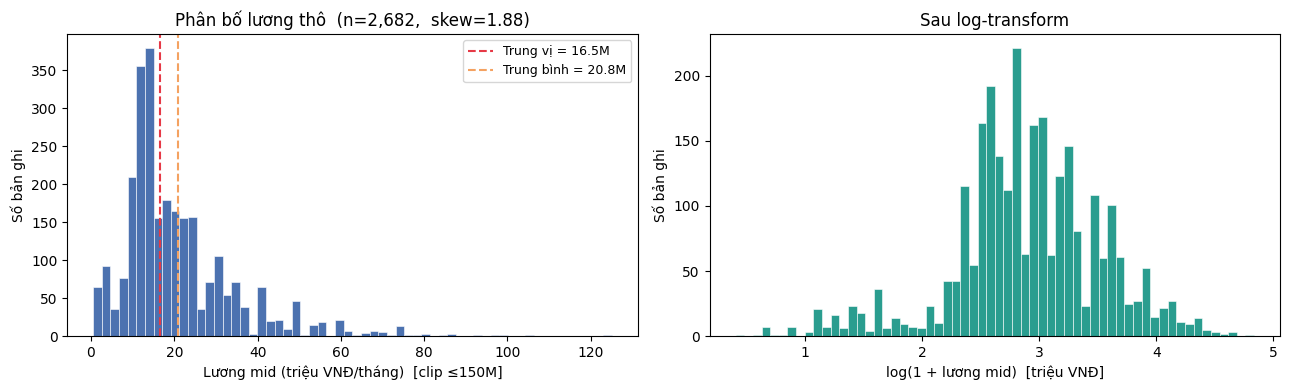

Skewness gốc: 1.88  → lệch phải, log-transform cải thiện chuẩn hóa
Giá trị cực đoan > 100M: 2 bản ghi
Giá trị cực đoan > 200M: 0 bản ghi


In [10]:
# Phân bố lương: histogram gốc + log-transform
from scipy import stats as scipy_stats

skew = round(float(scipy_stats.skew(all_mid)), 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(all_mid.clip(upper=150), bins=60, color="#4C72B0", edgecolor="white", lw=0.4)
axes[0].axvline(all_mid.median(), color="#e63946", ls="--", lw=1.5,
                label=f"Trung vị = {all_mid.median():.1f}M")
axes[0].axvline(all_mid.mean(),   color="#f4a261", ls="--", lw=1.5,
                label=f"Trung bình = {all_mid.mean():.1f}M")
axes[0].set_xlabel("Lương mid (triệu VNĐ/tháng)  [clip ≤150M]")
axes[0].set_ylabel("Số bản ghi")
axes[0].set_title(f"Phân bố lương thô  (n={len(all_mid):,},  skew={skew})")
axes[0].legend(fontsize=9)

axes[1].hist(np.log1p(all_mid), bins=60, color="#2a9d8f", edgecolor="white", lw=0.4)
axes[1].set_xlabel("log(1 + lương mid)  [triệu VNĐ]")
axes[1].set_ylabel("Số bản ghi")
axes[1].set_title("Sau log-transform")

plt.tight_layout()
plt.savefig("salary_dist.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Skewness gốc: {skew}  → lệch phải, log-transform cải thiện chuẩn hóa")
print(f"Giá trị cực đoan > 100M: {(all_mid > 100).sum()} bản ghi")
print(f"Giá trị cực đoan > 200M: {(all_mid > 200).sum()} bản ghi")

## 4. Trường `experience`

In [11]:
# TopCV: dạng categorical rõ ràng
print("=== TopCV — experience (tất cả giá trị unique) ===")
print(tc["experience"].value_counts(dropna=False).to_string())

print("\n=== ITViec — experience ===")
print(f"Null: {it['experience'].isna().sum()}  /  {len(it)}")
print(f"Non-null: {it['experience'].notna().sum()}")
if it["experience"].notna().any():
    print("Mẫu giá trị non-null:")
    print(it["experience"].dropna().head(10).to_string())

=== TopCV — experience (tất cả giá trị unique) ===
experience
1 năm            1125
2 năm            1019
3 năm             729
Không yêu cầu     486
Dưới 1 năm        401
NaN               218
5 năm             196
4 năm             127
Trên 5 năm         83

=== ITViec — experience ===
Null: 751  /  751
Non-null: 0


## 5. Trường `level`

In [12]:
print("=== TopCV — level ===")
print(tc["level"].value_counts(dropna=False).to_string())

print("\n=== ITViec — level ===")
print(it["level"].value_counts(dropna=False).to_string())

# Vì ITViec không có level, kiểm tra job_title xem có chứa cấp bậc không
print("\n=== ITViec — job_title (mẫu 15) ===")
print(it["job_title"].dropna().head(15).to_string())

# Thử trích cấp bậc từ job_title ITViec
LEVEL_PATTERN = re.compile(
    r"\b(intern|fresher|junior|mid[\s-]?level|middle|senior|lead|manager|"
    r"principal|director|head|staff|associate)\b", re.I
)
it["level_from_title"] = it["job_title"].str.extract(LEVEL_PATTERN, expand=False)
print("\nCấp bậc trích được từ job_title (ITViec):")
print(it["level_from_title"].value_counts(dropna=False).to_string())

=== TopCV — level ===
level
Nhân viên             3051
Trưởng nhóm            635
Thực tập sinh          275
NaN                    218
Trưởng/Phó phòng       111
Quản lý / Giám sát      81
Giám đốc                12
Trưởng chi nhánh         1

=== ITViec — level ===
level
NaN    751

=== ITViec — job_title (mẫu 15) ===
0             02 Back-end Developer (Golang, PostgreSQL, AWS)
1                           02 Mobile App Developer (Flutter)
2       03 Flutter Mobile Apps Developer (Dart, Android, iOS)
3                     03 Java Backend Developer (Spring, SQL)
4              03 Java/Kotlin Developers (All level, English)
5           03 Tester (Manual Tester, Automation Test, QA QC)
6           03 UI-UX Desginer (Photoshop, Illustrator, Figma)
7         04 Senior Fullstack Dev (Golang, Java, NodeJS, IOS)
8                   05 Senior/Lead Product Manager ( Fintech)
9                                     05 System Admin (Linux)
10     10 Mid/Senior Java Backend Developer (Spring, AI, S

## 6. Trường `location`

In [13]:
print("=== TopCV — top 20 location ===")
print(tc["location"].value_counts(dropna=False).head(20).to_string())

print("\n=== ITViec — top 20 location ===")
print(it["location"].value_counts(dropna=False).head(20).to_string())

# Kiểm tra format: 1 thành phố hay nhiều?
print("\n=== ITViec — ví dụ location có dấu phân cách ===")
multi = it["location"].dropna()
multi = multi[multi.str.contains(r"[,;|]|\ - ", regex=True)]
print(f"Có dấu phân cách: {len(multi)}")
print(multi.head(10).to_string())

=== TopCV — top 20 location ===
location
Hà Nội                                                                       2386
Hồ Chí Minh                                                                  1097
NaN                                                                           202
Đà Nẵng                                                                        79
Hải Phòng                                                                      33
Hưng Yên                                                                       28
- Hà Nội: MB Tower, Số 18 Lê Văn Lương, Phường Yên Hòa (quận Cầu Giấy cũ)      24
Bắc Ninh                                                                       23
Việc làm tại Hà Nội, Phường Cầu Giấy - Hà Nội                                  20
Nghệ An                                                                        19
Đồng Nai                                                                       17
Việc làm tại Hà Nội, Phường Thanh Xuân - Hà Nội          

## 7. Trường `required_skills` / `preferred_skills`

In [14]:
# Kiểm tra format raw của required_skills
for name, df in [("TopCV", tc), ("ITViec", it)]:
    col = df["required_skills"].dropna()
    print(f"=== {name} — required_skills ===")
    print(f"  Non-null: {len(col)} / {len(df)}")
    print("  Mẫu 5 giá trị:")
    for v in col.head(5):
        print(f"    {repr(str(v)[:120])}")
    print()

# Kiểm tra separator
print("Phân tích separator:")
for name, df in [("TopCV", tc), ("ITViec", it)]:
    col = df["required_skills"].dropna().astype(str)
    has_comma   = col.str.contains(",").sum()
    has_newline = col.str.contains(r"\n").sum()
    has_semi    = col.str.contains(";").sum()
    print(f"  {name}: comma={has_comma}  newline={has_newline}  semicolon={has_semi}")

=== TopCV — required_skills ===
  Non-null: 4384 / 4384
  Mẫu 5 giá trị:
    '[]'
    "['Swift (ios) Hoặc Kotlin Java (android)', 'Lập Trình Giao Diện Người Dùng (ui)']"
    "['Kỹ năng giao tiếp', 'Thiết kế đồ họa', 'Thiết Kế Hình Ảnh', 'Kỹ năng làm việc nhóm', 'Sáng tạo', 'Hiểu Biết Về Màu Sắc"
    "['Thiết Kế Hệ Thống', 'System Design', 'Backend Development']"
    '[]'

=== ITViec — required_skills ===
  Non-null: 751 / 751
  Mẫu 5 giá trị:
    'Golang, PostgreSql, AWS'
    'Flutter, Swift, Kotlin, Java'
    'Flutter, Android, iOS, Dart, Mobile Apps'
    'Java, Database, SQL, Oracle, Microservices, Spring'
    'Java, AWS, PostgreSql, Spring Boot, English, Kotlin'

Phân tích separator:
  TopCV: comma=2473  newline=0  semicolon=0
  ITViec: comma=751  newline=0  semicolon=0


In [15]:
# Phân bố số lượng skill tags mỗi bản ghi (dùng dấu phẩy làm separator)
def count_skills(s, sep=","):
    if pd.isna(s) or str(s).strip() == "":
        return 0
    return len([x for x in str(s).split(sep) if x.strip()])

for name, df in [("TopCV", tc), ("ITViec", it)]:
    n_skills = df["required_skills"].apply(count_skills)
    print(f"=== {name} — số skill mỗi tin ===")
    print(f"  0 skill (null/rỗng) : {(n_skills == 0).sum()}")
    print(f"  1-5 skill           : {((n_skills >= 1) & (n_skills <= 5)).sum()}")
    print(f"  6-10 skill          : {((n_skills >= 6) & (n_skills <= 10)).sum()}")
    print(f"  >10 skill           : {(n_skills > 10).sum()}")
    print(f"  Median              : {n_skills[n_skills > 0].median():.0f}")
    print(f"  Max                 : {n_skills.max()}")
    print()

=== TopCV — số skill mỗi tin ===
  0 skill (null/rỗng) : 0
  1-5 skill           : 3132
  6-10 skill          : 959
  >10 skill           : 293
  Median              : 3
  Max                 : 57

=== ITViec — số skill mỗi tin ===
  0 skill (null/rỗng) : 0
  1-5 skill           : 311
  6-10 skill          : 440
  >10 skill           : 0
  Median              : 6
  Max                 : 6



## 8. Trường `requirement` (văn bản dài)

In [16]:
# Trường này là input chính cho annotation — kiểm tra coverage và độ dài
for name, df in [("TopCV", tc), ("ITViec", it)]:
    col = df["requirement"].fillna("").astype(str).str.strip()
    has_text = col.str.len() > 10
    lengths  = col[has_text].str.len()
    print(f"=== {name} — requirement ===")
    print(f"  Có nội dung (>10 ký tự): {has_text.sum()} / {len(df)}")
    print(f"  Độ dài ký tự — min={lengths.min():.0f}  median={lengths.median():.0f}"
          f"  max={lengths.max():.0f}  mean={lengths.mean():.0f}")
    print(f"  Mẫu 1 bản ghi:")
    sample = df.loc[has_text, "requirement"].iloc[0]
    print(f"    {repr(str(sample)[:300])}")
    print()

=== TopCV — requirement ===
  Có nội dung (>10 ký tự): 4166 / 4384
  Độ dài ký tự — min=76  median=545  max=4149  mean=615
  Mẫu 1 bản ghi:
    '- Tốt nghiệp Đại học, Cao đẳng, trung tâm đào tạo chuyên ngành CNTT. - Có hiểu biết về ASP.NET, OOP, RESFULL, Design Patterns. - Có hiểu biết về lập trình Backend – Frontend, Javascript, HTML, CSS, HTTP. - Nắm vững kiến thức cơ bản về lập trình SQL và hiểu biết về SQL Server hoặc Oracle Database. - '

=== ITViec — requirement ===
  Có nội dung (>10 ký tự): 751 / 751
  Độ dài ký tự — min=177  median=943  max=4320  mean=1068
  Mẫu 1 bản ghi:
    'Responsibilities:\r\nDevelop and maintain microservices using Golang, gRPC, AWS\r\nImplement RESTful API\r\nImplement and manage PostgreSQL databases\r\nCollaborate with cross-functional Firmware and Mobile App teams to define, design, and ship new features\r\nTroubleshoot, debug, and upgrade existing systems'



## 9. Trường `industry` & `employment_type`

In [17]:
print("=== TopCV — industry (top 15) ===")
print(tc["industry"].value_counts(dropna=False).head(15).to_string())

print("\n=== ITViec — industry (top 15) ===")
print(it["industry"].value_counts(dropna=False).head(15).to_string())

print("\n=== TopCV — employment_type ===")
print(tc["employment_type"].value_counts(dropna=False).to_string())

print("\n=== ITViec — employment_type ===")
print(it["employment_type"].value_counts(dropna=False).to_string())

=== TopCV — industry (top 15) ===
industry
IT - Phần mềm                            2020
NaN                                       283
Marketing / Truyền thông / Quảng cáo      263
Sản xuất                                  186
Bán lẻ - Hàng tiêu dùng - FMCG            166
Giáo dục / Đào tạo                        162
Khác                                      156
Dược phẩm / Y tế / Công nghệ sinh học     125
Bất động sản                               97
Viễn thông                                 88
Thương mại điện tử                         87
Tài chính                                  85
Thời trang                                 62
IT - Phần cứng                             51
Nhà hàng / Khách sạn                       49

=== ITViec — industry (top 15) ===
industry
IT Services and IT Consulting              204
Software Products and Web Services         140
Banking                                     99
Financial Services                          81
Software Development Outsourcing  

## 10. Tóm tắt số liệu thô

In [18]:
n_tc, n_it = len(tc), len(it)
n_total = n_tc + n_it

tc_sal_num = tc["sal_mid"].notna().sum()
it_sal_num = it["sal_mid"].notna().sum()

print("=" * 60)
print("TÓM TẮT SỐ LIỆU THÔ")
print("=" * 60)
print(f"\nKích thước tập dữ liệu")
print(f"  TopCV  : {n_tc:,} bản ghi  ×  {tc.shape[1]} cột")
print(f"  ITViec : {n_it:,} bản ghi  ×  {it.shape[1]} cột")
print(f"  Tổng   : {n_total:,} bản ghi")
print(f"  Cột chung: {len(common)}  |  Chỉ TC: {len(only_tc)}  |  Chỉ IT: {len(only_it)}")

print(f"\nTỷ lệ lương số hóa được (có giá trị số)")
print(f"  TopCV  : {tc_sal_num:,} / {n_tc:,}  ({tc_sal_num/n_tc*100:.1f}%)")
print(f"  ITViec : {it_sal_num:,} / {n_it:,}  ({it_sal_num/n_it*100:.1f}%)")
print(f"  Tổng   : {tc_sal_num+it_sal_num:,} / {n_total:,}  "
      f"({(tc_sal_num+it_sal_num)/n_total*100:.1f}%)")

print(f"\nPhân bố lương (n={len(all_mid):,} bản ghi số hóa được, triệu VNĐ/tháng)")
print(f"  Trung vị   : {all_mid.median():.1f}")
print(f"  Trung bình : {all_mid.mean():.1f}")
print(f"  P5 / P95   : {np.percentile(all_mid,5):.1f}  /  {np.percentile(all_mid,95):.1f}")
print(f"  Skewness   : {scipy_stats.skew(all_mid):.2f}")

print(f"\nTrường thiếu đáng chú ý")
for col in ["level", "experience", "education", "specialization"]:
    tc_m = tc[col].isna().sum() / n_tc * 100
    it_m = it[col].isna().sum() / n_it * 100
    print(f"  {col:20s}  TC={tc_m:5.1f}%   IT={it_m:5.1f}%")

print(f"\nTrùng lặp")
print(f"  Trùng URL nội bộ        : TC={tc['url'].duplicated().sum()}  IT={it['url'].duplicated().sum()}")
print(f"  Trùng URL xuyên nguồn   : {it['url'].isin(tc['url']).sum()}")
print(f"  Trùng nội dung mềm      : {n_soft_dup}  ({n_soft_dup/n_total*100:.1f}%)")

TÓM TẮT SỐ LIỆU THÔ

Kích thước tập dữ liệu
  TopCV  : 4,384 bản ghi  ×  19 cột
  ITViec : 751 bản ghi  ×  19 cột
  Tổng   : 5,135 bản ghi
  Cột chung: 15  |  Chỉ TC: 1  |  Chỉ IT: 0

Tỷ lệ lương số hóa được (có giá trị số)
  TopCV  : 2,498 / 4,384  (57.0%)
  ITViec : 184 / 751  (24.5%)
  Tổng   : 2,682 / 5,135  (52.2%)

Phân bố lương (n=2,682 bản ghi số hóa được, triệu VNĐ/tháng)
  Trung vị   : 16.5
  Trung bình : 20.8
  P5 / P95   : 4.0  /  50.0
  Skewness   : 1.88

Trường thiếu đáng chú ý
  level                 TC=  5.0%   IT=100.0%
  experience            TC=  5.0%   IT=100.0%
  education             TC=  5.0%   IT=100.0%
  specialization        TC=  0.0%   IT=100.0%

Trùng lặp
  Trùng URL nội bộ        : TC=0  IT=0
  Trùng URL xuyên nguồn   : 0
  Trùng nội dung mềm      : 246  (4.8%)


In [19]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.1f}".format)

# ── Load dữ liệu thô ──────────────────────────────────────────────────────────
it = pd.read_csv("../data/raw/00-itviec_raw.csv")
tc = pd.read_csv("../data/raw/00-topcv_raw.csv")

it["source"] = "itviec"
tc["source"] = "topcv"

print(f"ITViec : {it.shape[0]:,} bản ghi × {it.shape[1]-1} trường")
print(f"TopCV  : {tc.shape[0]:,} bản ghi × {tc.shape[1]-1} trường")
print(f"Tổng   : {it.shape[0] + tc.shape[0]:,} bản ghi")

ITViec : 751 bản ghi × 15 trường
TopCV  : 4,384 bản ghi × 16 trường
Tổng   : 5,135 bản ghi
